In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, BatchNormalization, MaxPooling2D
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Loading and preprocessng the CIFAR-10 dataset



In [3]:
# Loading CIFAR-10 data
(x_train, y_train) , (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One hot encode the labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


## Define  Alexnet Model (Adjusted for CIFAR-10)
>* Adjusted to CIFAR-10's 32 x 32 input size and 10 output classes.

>* Reduced FC layers from 4096->1024-> 512 to avoid the overfitting on small images

>* Uses ReLU , Dropout, BatchNorm and softmax in the final layer


In [4]:
model = Sequential()

# Layer 1
model.add(Conv2D(96, kernel_size=(3, 3), strides=(1, 1), input_shape=(32, 32, 3), padding="same"))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())

# Layer 2
model.add(Conv2D(256, kernel_size=(5, 5), strides=(1, 1), padding="same"))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())

# Layer 3
model.add(Conv2D(384, kernel_size=(3, 3), strides=(1, 1), padding='same'))
model.add(Activation('relu'))

# Layer 4
model.add(Conv2D(384, kernel_size=(3, 3), strides=(1, 1), padding='same'))
model.add(Activation('relu'))

# Layer 5
model.add(Conv2D(256, kernel_size=(3, 3), strides=(1, 1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Flatten
model.add(Flatten())

# Fully connected Layer 1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Fully connected Layer 2
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10))
model.add(Activation('softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(loss="categorical_crossentropy",
              optimizer='adam',
              metrics=['accuracy'])


In [6]:
history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=15,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.3023 - loss: 1.9282 - val_accuracy: 0.0980 - val_loss: 7.6393
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.5536 - loss: 1.2507 - val_accuracy: 0.3567 - val_loss: 2.3957
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.6492 - loss: 1.0092 - val_accuracy: 0.6419 - val_loss: 1.0664
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7058 - loss: 0.8502 - val_accuracy: 0.6059 - val_loss: 1.1266
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.7589 - loss: 0.7024 - val_accuracy: 0.6426 - val_loss: 1.0910
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.7925 - loss: 0.5945 - val_accuracy: 0.6995 - val_loss: 0.8823
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8273 - loss: 0.5074 - val_accuracy: 0.7264 - val_loss: 0.7843
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8574 - loss: 0.4218 - 

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7489


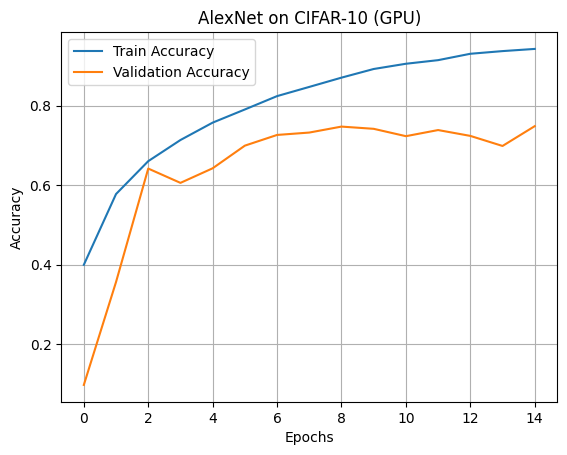

In [8]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('AlexNet on CIFAR-10 (GPU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()